# Homework 2 — Machine Learning for Regression

ML Zoomcamp 2026 · Module 2

Assignment: [cohorts/2026/homework/02-regression](https://github.com/DataTalksClub/machine-learning-zoomcamp/blob/main/cohorts/2026/homework/02-regression/homework.md)

Goal: build a linear regression model that predicts car fuel efficiency
(`fuel_efficiency_mpg`) — implemented from scratch with NumPy, no scikit-learn.

Due: **28 Sep 2026, 23:00 UTC**

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

---
## Getting the data

2026 Car Fuel Efficiency dataset — the same file as module 1. Run the cell below
once to download it into `data/`.

In [2]:
!mkdir -p data && curl -sSL -o data/car_fuel_efficiency_2026.csv \
    https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv

In [3]:
df_full = pd.read_csv('data/car_fuel_efficiency_2026.csv')
df_full.shape

(10000, 11)

### Preparing the dataset

Use **only** these columns — everything below works on this filtered frame:

* `engine_displacement`
* `horsepower`
* `vehicle_weight`
* `model_year`
* `fuel_efficiency_mpg`  ← target

In [4]:
columns = [
    'engine_displacement',
    'horsepower',
    'vehicle_weight',
    'model_year',
    'fuel_efficiency_mpg',
]

df = df_full[columns]
df.head()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,2180,243.0,3870,2006,31.9
1,2390,272.0,4210,2008,31.3
2,2320,267.0,4240,1996,27.5
3,2130,258.0,4490,1989,28.5
4,2580,304.0,4510,1994,31.0


---
## EDA

Look at the `fuel_efficiency_mpg` variable. Does it have a long tail?

<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

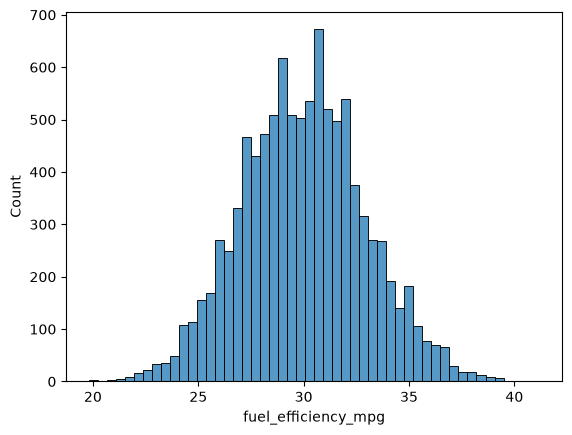

In [5]:
# Plot the distribution of the target
sns.histplot(df.fuel_efficiency_mpg, bins=50)

> **Note the difference from the lecture.** In the car-price project the target
> (`msrp`) had a long tail, so we applied `np.log1p`. Check whether that's the
> case here before copying that step over — if the target is already roughly
> symmetric, transforming it would shift every RMSE and none of your answers
> would match the options.

---
## Q1. Missing values

There's one column with missing values. What is it?

*Options: `engine_displacement` / `horsepower` / `vehicle_weight` / `model_year`*

In [6]:
# Q1
df.isnull().sum()

engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

---
## Q2. Median of horsepower

What's the median (50% percentile) for variable `horsepower`?

*Options: 204 / 254 / 304 / 354*

In [7]:
# Q2
df.horsepower.describe()

count    9123.000000
mean      254.446016
std        22.844613
min       171.000000
25%       239.000000
50%       254.000000
75%       270.000000
max       334.000000
Name: horsepower, dtype: float64

---
## Helper functions

These come straight from the lectures. Write them once here and reuse them for
Q3–Q6. Reference: [unit 2.7 — normal equation](https://github.com/DataTalksClub/machine-learning-zoomcamp/blob/main/02-regression/07-linear-regression-training.md)
and [unit 2.13 — regularization](https://github.com/DataTalksClub/machine-learning-zoomcamp/blob/main/02-regression/13-regularization.md).

In [8]:
def train_linear_regression(X, y):    
    X = np.column_stack([np.ones(X.shape[0]), X])
    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    return w_full[0], w_full[1:]

In [9]:
def train_linear_regression_reg(X, y, r=0.0):    
    X = np.column_stack([np.ones(X.shape[0]), X])
    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    return w_full[0], w_full[1:]

In [10]:
def rmse(y, y_pred):    
    return np.sqrt(np.mean((y - y_pred)**2))

---
## Prepare and split the dataset

Shuffle the filtered dataset and split 60% / 20% / 20%, exactly as in the lecture:

```python
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]
```

Q5 repeats this with seeds 0–9 and Q6 uses seed 9, so it pays to wrap it in a
function that takes the seed and returns the three frames.

In [11]:
def split_data(df, seed):
    n = len(df)
    n_val = int(n * 0.2)
    n_test = int(n * 0.2)
    n_train = n - n_val - n_test

    np.random.seed(seed)
    idx = np.arange(n)
    np.random.shuffle(idx)

    df_train = df.iloc[idx[:n_train]]
    df_val = df.iloc[idx[n_train:n_train + n_val]]
    df_test = df.iloc[idx[n_train + n_val:]]
    return df_train, df_val, df_test

In [12]:
def prepare_X(df_part, fillna_value=0.0):   
    df_num = df_part[['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year']]          
    df_num = df_num.fillna(fillna_value)
    return df_num.values                

In [13]:
def evaluate(df_train, df_val, y_train, y_val, fillna_value=0.0, r=None):
    X_train = prepare_X(df_train, fillna_value)
    X_val = prepare_X(df_val, fillna_value)
    if r is None:
        w0, w = train_linear_regression(X_train, y_train)
    else:
        w0, w = train_linear_regression_reg(X_train, y_train, r)
    return rmse(y_val, w0 + X_val.dot(w))

---
## Q3. Filling missing values: 0 vs mean

* Deal with missing values for the column from Q1.
* Two options: fill with `0`, or fill with the **mean** of that variable.
* For each option, train a linear regression **without** regularization.
* Compute the mean on the **training set only** — using the full dataset here is
  a leak, and it's the most common mistake in this homework.
* Evaluate on the validation set, round with `round(score, 3)`.

*Options: With 0 / With mean / Both are equally good*

In [14]:
df_train, df_val, df_test = split_data(df, 42)
y_train, y_val, y_test = df_train.fuel_efficiency_mpg.values, df_val.fuel_efficiency_mpg.values, df_test.fuel_efficiency_mpg.values

In [15]:
# Q3 — split with seed 42, build y_train / y_val, then compare the two options
hp_mean = df_train.horsepower.mean()
print(f"RMSE (0 filled) = {round(evaluate(df_train, df_val, y_train, y_val, fillna_value=0), 3)}")
print(f"RMSE (mean filled) = {round(evaluate(df_train, df_val, y_train, y_val, fillna_value=hp_mean), 3)}")

RMSE (0 filled) = 2.205
RMSE (mean filled) = 2.202


---
## Q4. Regularization

* Train a regularized linear regression, filling NAs with `0`.
* Try `r` in `[0, 0.01, 0.1, 1, 5, 10, 100]`.
* Evaluate on validation, round with `round(score, 4)`.
* Which `r` gives the best RMSE? If several tie, pick the smallest `r`.

*Options: 0 / 0.01 / 0.1 / 1 / 5 / 10 / 100*

In [16]:
# Q4
for r in [0, 0.01, 0.1, 1, 5, 10, 100]:
    print(f"r={r:<6} RMSE = {round(evaluate(df_train, df_val, y_train, y_val, fillna_value=0, r= r), 4)}")

r=0      RMSE = 2.2053
r=0.01   RMSE = 2.2058
r=0.1    RMSE = 2.2241
r=1      RMSE = 2.3492
r=5      RMSE = 2.4094
r=10     RMSE = 2.4195
r=100    RMSE = 2.4292


---
## Q5. How much does the seed matter?

* Try seeds `[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]`.
* For each: split 60/20/20, fill NAs with `0`, train **without** regularization,
  score on validation.
* Take `np.std` of the 10 scores, round with `round(std, 3)`.

*Options: 0.006 / 0.016 / 0.029 / 0.036*

> A low standard deviation means the model is *stable* — the score doesn't depend
> much on which rows happened to land in the validation set.

In [17]:
# Q5
scores = []

for seed in range(10):
    df_tr, df_v, _ = split_data(df, seed)
    y_tr = df_tr.fuel_efficiency_mpg.values
    y_v = df_v.fuel_efficiency_mpg.values

    score = evaluate(df_tr, df_v, y_tr, y_v, fillna_value=0)
    scores.append(score)
    print(f"seed={seed}  RMSE = {score:.4f}")

std = np.std(scores)
print(f"\nstd = {round(std, 3)}")


seed=0  RMSE = 2.2392
seed=1  RMSE = 2.2021
seed=2  RMSE = 2.1634
seed=3  RMSE = 2.2044
seed=4  RMSE = 2.2019
seed=5  RMSE = 2.2458
seed=6  RMSE = 2.2697
seed=7  RMSE = 2.1908
seed=8  RMSE = 2.2166
seed=9  RMSE = 2.2070

std = 0.029


---
## Q6. Final model on the test set

* Split with seed `9`.
* Combine train and validation into one frame (`pd.concat`) — and `np.concatenate`
  for the targets.
* Fill NAs with `0`, train with `r=0.001`.
* What's the RMSE on the **test** set?

*Options: 0.236 / 2.236 / 22.10 / 221.0*

In [18]:
# Q6
df_tr, df_v, df_te = split_data(df, 9)

# train + validation gop lam mot
df_full_train = pd.concat([df_tr, df_v]).reset_index(drop=True)
y_full_train = np.concatenate([
    df_tr.fuel_efficiency_mpg.values,
    df_v.fuel_efficiency_mpg.values,
])
y_te = df_te.fuel_efficiency_mpg.values

score = evaluate(df_full_train, df_te, y_full_train, y_te, fillna_value=0, r=0.001)
print(f"RMSE on test = {round(score, 3)}")


RMSE on test = 2.236


---
## Answers

| Question | Answer | Computed value |
|---|---|---|
| Q1 — column with missing values | `horsepower` | 877 NAs |
| Q2 — median of horsepower | **254** | 254.0 |
| Q3 — 0 or mean | **With mean** | 2.205 (zero) vs 2.202 (mean) |
| Q4 — best `r` | **0** | 2.2053; RMSE rises monotonically with `r` |
| Q5 — std of scores | **0.029** | scores span 2.163 – 2.270 |
| Q6 — RMSE on test | **2.236** | seed 9, train+val, `r=0.001` |

Two things worth noting beyond the answers:

- **Regularization does nothing here** (Q4). In the lecture `r` rescued a model
  whose RMSE had blown up to 41, because one-hot encoding produced near-duplicate
  columns and `XᵀX` was close to singular. This homework has 4 independent
  numerical features, so `XᵀX` is well-conditioned and adding `r` only shrinks the
  weights for no reason.
- **The Q3 gap is smaller than the seed noise.** Filling with the mean beats zero
  by 0.003, but Q5 shows that reshuffling the split moves the score by ~0.029 —
  ten times more. So "mean is better" holds for this particular split, not as a
  general claim about the two imputation strategies.

**Reflection** (asked on the submission form): *Describe one practical idea you
took from this module.*

>
